# Prac 07.2

In this homework you are going to inspect the **GTSRB** (German Traffic Sign Recognition Benchmark) dataset.
The dataset contains images of 43 classes of traffic signs used in Germany and across the EU.
The objective is to go through the steps below and answer the questions at the end.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from collections import Counter
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

The **GTSRB** dataset is the German Traffic Sign Recognition Benchmark.
It was introduced at IJCNN 2011 and contains over 50 000 images of 43 traffic-sign categories captured
from real driving sequences under varying lighting, weather and motion-blur conditions.
Images have variable resolution (roughly 25–250 px per side) and are provided with tight bounding-box annotations.
The full dataset is available at [benchmark.ini.rub.de](https://benchmark.ini.rub.de/gtsrb_dataset.html).

### Step 1 — Dataset location

The dataset has been extracted to `../GTSRB/GTSRB/Training/`.  
A unified `Train.csv` (built from the per-class annotation files) is located at `../GTSRB/Train.csv`.

### Step 2 — Load `Train.csv` and visualise random samples

In [2]:
# Root path for images (relative to this notebook)
root = '../GTSRB/GTSRB'
csv_path = '../GTSRB/Train.csv'

data = pd.read_csv(csv_path)
num_samples = len(data)

print(f'Total training samples: {num_samples}')
print(f'Columns: {data.columns.tolist()}')
print(f'Number of classes: {data["ClassId"].nunique()}')
data.head(3)

Total training samples: 26640
Columns: ['Filename', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Number of classes: 43


,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,00000_00000.ppm,29,30,5,6,24,25,0,Training/00000/00000_00000.ppm
1,00000_00001.ppm,30,30,5,5,25,25,0,Training/00000/00000_00001.ppm
2,00000_00002.ppm,30,30,5,5,25,25,0,Training/00000/00000_00002.ppm


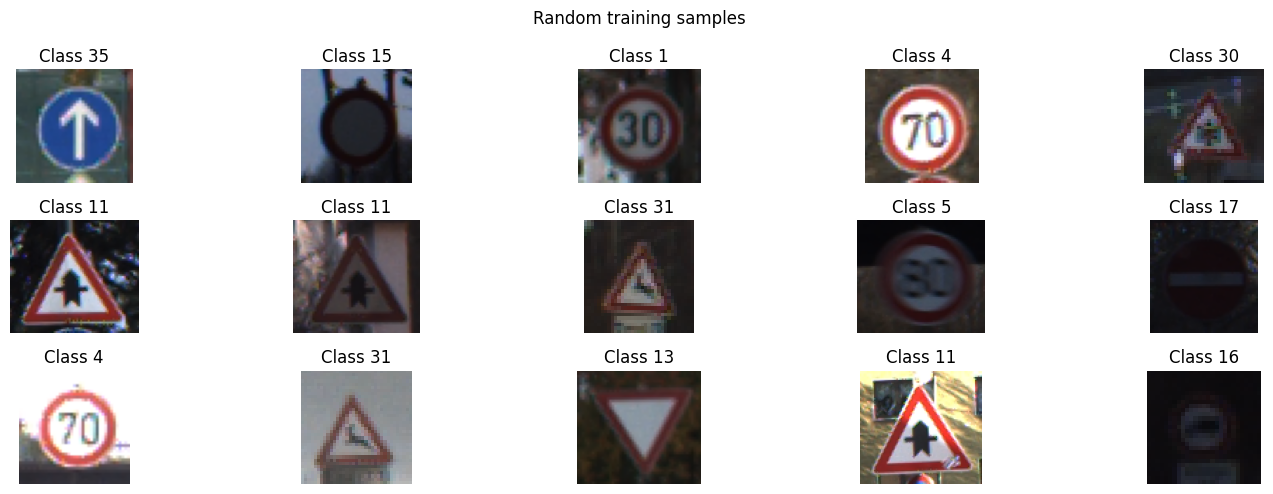

In [3]:
# Show 15 random samples
np.random.seed(42)
plt.figure(figsize=(15, 5))
for ii in range(15):
    idx = np.random.randint(0, num_samples)
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 5, ii+1)
    plt.imshow(img)
    plt.title(f'Class {data.iloc[idx]["ClassId"]}')
    plt.axis('off')
plt.suptitle('Random training samples')
plt.tight_layout()

### Step 3 — Per-class histogram

Most common class:  ID=1, count=1500
Least common class: ID=0, count=150
Mean count: 620,  Std: 457


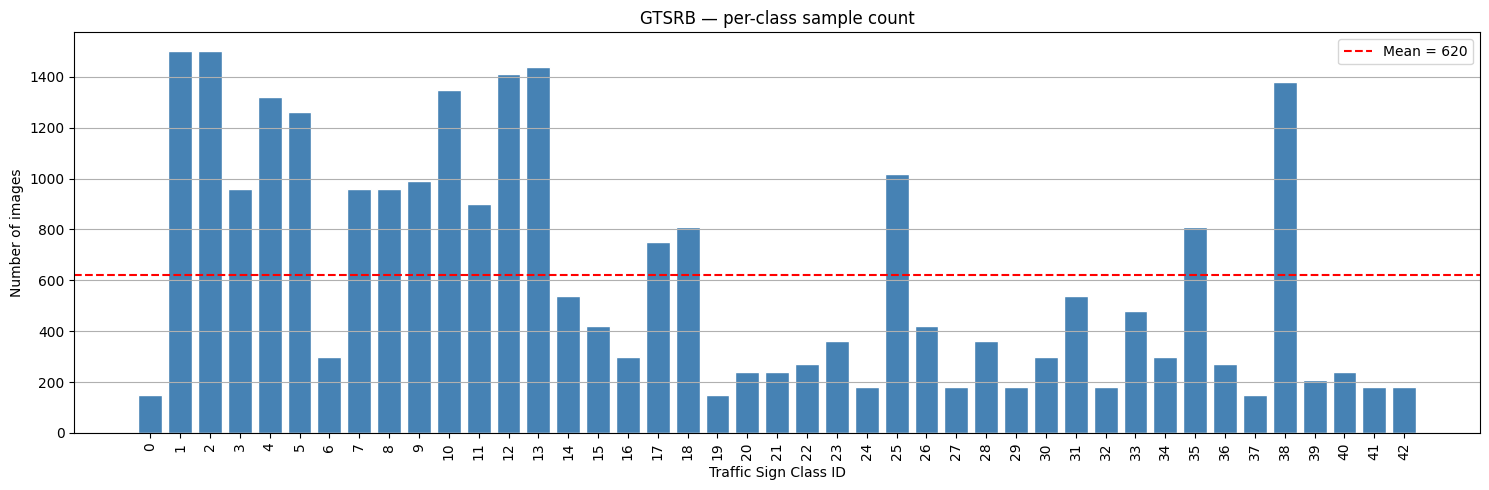

In [4]:
# Extract class identifiers
ids = data['ClassId'].tolist()

hist = Counter(ids)

keys = sorted(hist.keys())
vals = [hist[k] for k in keys]

plt.figure(figsize=(15, 5))
plt.bar(keys, vals, color='steelblue', edgecolor='white')
plt.axhline(np.mean(vals), color='red', linestyle='--', label=f'Mean = {np.mean(vals):.0f}')
plt.xlabel('Traffic Sign Class ID'), plt.ylabel('Number of images')
plt.title('GTSRB — per-class sample count')
plt.legend(), plt.grid(axis='y')
plt.xticks(keys, rotation=90)
plt.tight_layout()

print(f'Most common class:  ID={max(hist, key=hist.get)}, count={max(hist.values())}')
print(f'Least common class: ID={min(hist, key=hist.get)}, count={min(hist.values())}')
print(f'Mean count: {np.mean(vals):.0f},  Std: {np.std(vals):.0f}')

### Questions

**Q1: Is the dataset balanced?**

No, the dataset is **highly imbalanced**. The most common class (class 1) has 1 500 samples while the rarest class (class 0) has only 150 — a 10:1 ratio. The standard deviation across classes (~463 samples) is large relative to the mean (~620), confirming strong imbalance.

**Q2: Are any classes significantly over- or under-represented?**

Yes:
- **Over-represented:** Classes 1, 2, and 3 (speed limit signs) each have 1 500 images, well above the mean. These are presumably the most frequently encountered signs in real driving.
- **Under-represented:** Class 0 has only 150 images (10% of the largest class), and several other classes have fewer than 300 samples.

This imbalance reflects real-world traffic sign frequency: common speed limit signs appear far more often than rare warning or prohibition signs. For training a balanced classifier, techniques such as **class-weighted loss**, **oversampling** (e.g. SMOTE), or **data augmentation** would be needed.

### Optional — Advanced dataset analysis

Width  range: 25 - 243 px,  mean: 50.9
Height range: 25 - 225 px,  mean: 50.4


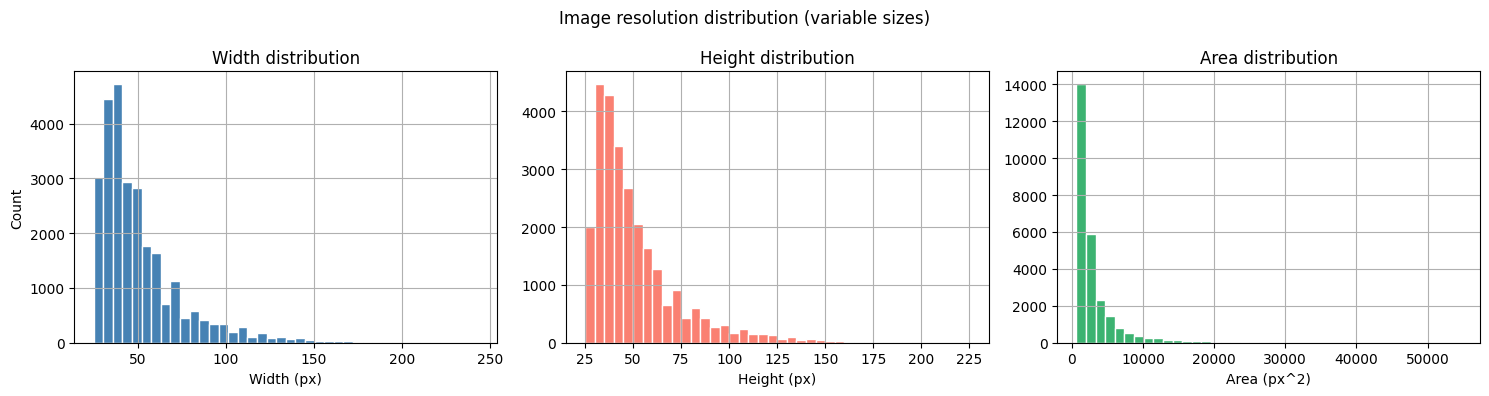

In [5]:
# Hint 1: Resolution distribution
# Unlike MNIST/CIFAR10, GTSRB images have variable spatial resolution.
widths  = data['Width'].values
heights = data['Height'].values
areas   = widths * heights

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths,  bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Width (px)'), axes[0].set_ylabel('Count')
axes[0].set_title('Width distribution'), axes[0].grid(True)

axes[1].hist(heights, bins=40, color='salmon', edgecolor='white')
axes[1].set_xlabel('Height (px)')
axes[1].set_title('Height distribution'), axes[1].grid(True)

axes[2].hist(areas, bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_xlabel('Area (px^2)')
axes[2].set_title('Area distribution'), axes[2].grid(True)

plt.suptitle('Image resolution distribution (variable sizes)')
plt.tight_layout()

print(f'Width  range: {widths.min()} - {widths.max()} px,  mean: {widths.mean():.1f}')
print(f'Height range: {heights.min()} - {heights.max()} px,  mean: {heights.mean():.1f}')

Brightest class: 35 (133.2)
Darkest class:   6   (38.2)


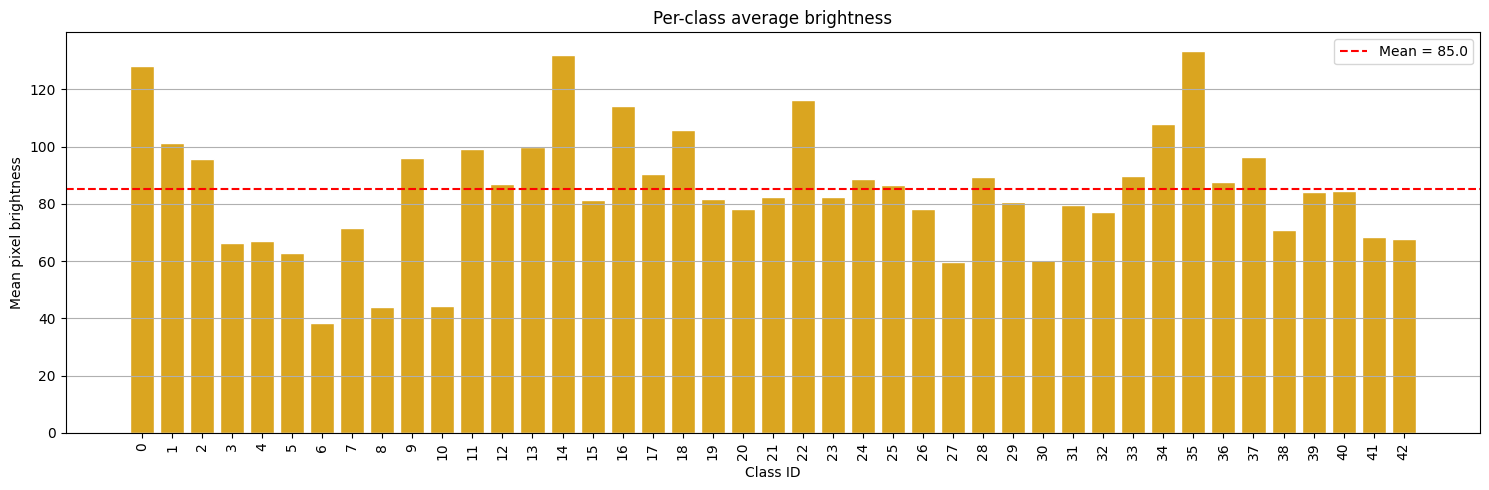

In [6]:
# Hint 2: Per-class brightness distribution
# Sample a few images per class and compute mean brightness
class_brightness = {}
np.random.seed(0)

for class_id in range(43):
    rows = data[data['ClassId'] == class_id]
    sample = rows.sample(min(20, len(rows)), random_state=0)
    means = []
    for _, row in sample.iterrows():
        img = cv2.imread(os.path.join(root, row['Path']), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            means.append(img.mean())
    class_brightness[class_id] = np.mean(means)

bkeys = list(class_brightness.keys())
bvals = [class_brightness[k] for k in bkeys]

plt.figure(figsize=(15, 5))
plt.bar(bkeys, bvals, color='goldenrod', edgecolor='white')
plt.axhline(np.mean(bvals), color='red', linestyle='--', label=f'Mean = {np.mean(bvals):.1f}')
plt.xlabel('Class ID'), plt.ylabel('Mean pixel brightness')
plt.title('Per-class average brightness')
plt.xticks(bkeys, rotation=90)
plt.legend(), plt.grid(axis='y')
plt.tight_layout()

brightest = max(class_brightness, key=class_brightness.get)
darkest   = min(class_brightness, key=class_brightness.get)
print(f'Brightest class: {brightest} ({class_brightness[brightest]:.1f})')
print(f'Darkest class:   {darkest}   ({class_brightness[darkest]:.1f})')

**Observations from the optional analysis:**

- **Resolution:** Images range from 25 px to ~240 px per side. Most images cluster around 30–70 px — small crops of traffic signs from video frames. Any model must resize inputs to a fixed size before feeding them into a neural network.
- **Brightness:** There is noticeable variation in mean brightness across classes. Some classes (e.g. white background signs like speed limits) are systematically brighter than dark-background signs (e.g. priority/hazard triangles). This means brightness alone could partially distinguish some classes, but a deep model should learn to ignore illumination variation.